In [75]:
#!unzip "/content/data_klasifikasi_batik-20240923T142326Z-001.zip" -d "/content/data_klasifikasi_batikk"

In [76]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
def view_random_image(target_dir,target_class):
  target_folder = target_dir + target_class
  random_image = random.sample(os.listdir(os.path.join(target_dir, target_class)),1)

  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  print(f"Ukuran gambar:{img.shape}")
  return img

Ukuran gambar:(500, 500, 3)


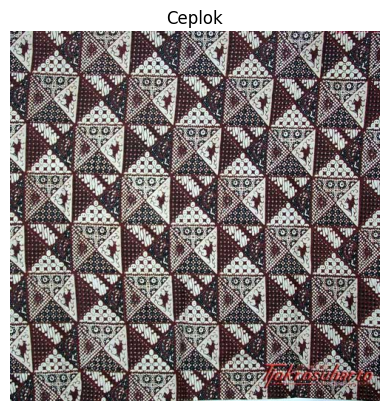

In [77]:
img = view_random_image("/content/data_klasifikasi_batikk/data_klasifikasi_batik/train/","Ceplok")

In [78]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint

In [79]:
tf.random.set_seed(46)

In [80]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [81]:
train_dir = "/content/data_klasifikasi_batikk/data_klasifikasi_batik/train"
valid_dir = "/content/data_klasifikasi_batikk/data_klasifikasi_batik/test"

In [82]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=16,
                                               target_size=(450, 450),
                                               class_mode="categorical",
                                               shuffle=True)
valid_data = valid_datagen.flow_from_directory(valid_dir,
                                               batch_size=16,
                                               target_size=(450, 450),
                                               class_mode="categorical",
                                               shuffle=True)


Found 511 images belonging to 6 classes.
Found 129 images belonging to 6 classes.


In [83]:
model_1 = Sequential([
                      Conv2D(10,3,activation='relu'),
                      MaxPool2D(2),
                      Conv2D(10,3,activation='relu'),
                      MaxPool2D(2),
                      Flatten(),
                      Dense(6, activation= "softmax")
                      ])

In [84]:
model_1.compile(loss="categorical_crossentropy",
                optimizer=Adam(),
                metrics=['accuracy'])

In [85]:
history_1 = model_1.fit(train_data,
                        epochs=40,
                        validation_data=valid_data,)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.2325 - loss: 7.4036 - val_accuracy: 0.2093 - val_loss: 1.8089
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.4959 - loss: 1.6426 - val_accuracy: 0.2558 - val_loss: 1.9580
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.5383 - loss: 1.3386 - val_accuracy: 0.2946 - val_loss: 1.9816
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.7021 - loss: 0.9277 - val_accuracy: 0.3256 - val_loss: 1.9088
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.8477 - loss: 0.5692 - val_accuracy: 0.3256 - val_loss: 2.0989
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step - accuracy: 0.8738 - loss: 0.5617 - val_accuracy: 0.4031 - val_loss: 2.3681
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.8744 - loss: 0.4896 - val_accuracy: 0.3101 - val_loss: 2.2433
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.9273 - loss: 0.4015 - val_accuracy

In [86]:
def plot_loss_curves(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(history.history['loss']))

    #plot
    plt.plot(epochs,loss,label = 'training_loss')
    plt.plot(epochs,val_loss,label = 'val_loss')
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    plt.figure()
    plt.plot(epochs,accuracy,label = 'training_acc')
    plt.plot(epochs,val_accuracy,label = 'val_acc')
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

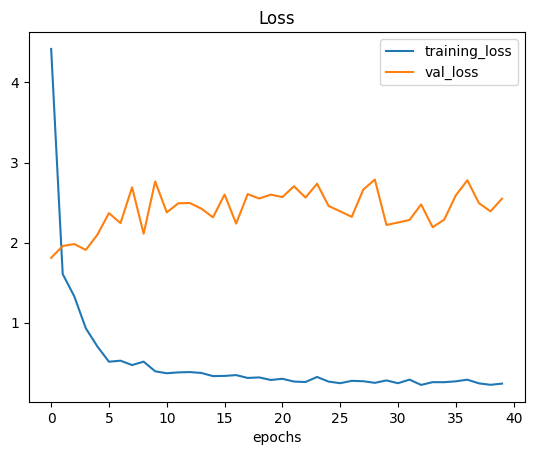

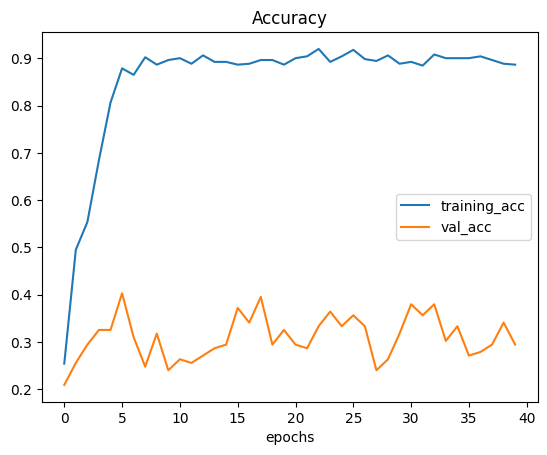

In [87]:
plot_loss_curves(history_1)

In [88]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi data untuk memperkaya variasi dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,  # Putar gambar untuk augmentasi
    width_shift_range=0.2,  # Pindahkan gambar secara horizontal
    height_shift_range=0.2,  # Pindahkan gambar secara vertikal
    shear_range=0.15,  # Distorsi gambar
    zoom_range=0.3,  # Zoom untuk augmentasi
    horizontal_flip=True,  # Flip gambar secara horizontal
    fill_mode='nearest'  # Cara mengisi ulang piksel yang hilang setelah augmentasi
)

valid_datagen = ImageDataGenerator(rescale=1./255)


In [89]:
train_data_augmented = train_datagen.flow_from_directory(train_dir,
                                                        batch_size=32,
                                                        target_size=(450,450),
                                                        class_mode="categorical",
                                                        shuffle=True)

Found 511 images belonging to 6 classes.


In [90]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model_2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(450, 450, 3)),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.4),

    # Tambahkan layer konvolusi tambahan
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.4),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.5),

    Flatten(),

    Dense(256, activation='relu'),  # Tambah unit dalam Dense layer
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(6, activation='softmax')  # Sesuaikan dengan jumlah kelas
])


model_2.compile(loss="categorical_crossentropy",
                optimizer=Adam(),
                metrics=['accuracy'])


history_2 = model_2.fit(train_data_augmented,
                        epochs=40,
                        validation_data=valid_data)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.1989 - loss: 2.8325 - val_accuracy: 0.1318 - val_loss: 4.4880
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.2210 - loss: 2.6222 - val_accuracy: 0.1318 - val_loss: 3.7127
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.2703 - loss: 2.2222 - val_accuracy: 0.1318 - val_loss: 5.5916
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2777 - loss: 2.1771 - val_accuracy: 0.1318 - val_loss: 5.4593
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2908 - loss: 2.1579 - val_accuracy: 0.1318 - val_loss: 5.3308
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.2888 - loss: 2.0820 - val_accuracy: 0.1318 - val_loss: 4.1130
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3320 - loss: 1.9488 - val_accuracy: 0.1318 - val_loss: 4.5742
Epoch 8/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3571 - loss: 1.7955 - val_accuracy: 0.1318 - val_loss:

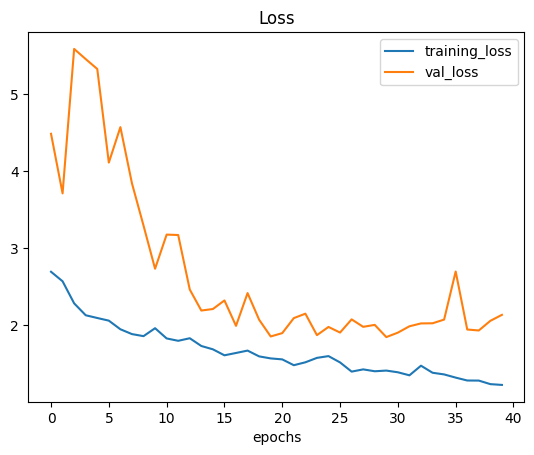

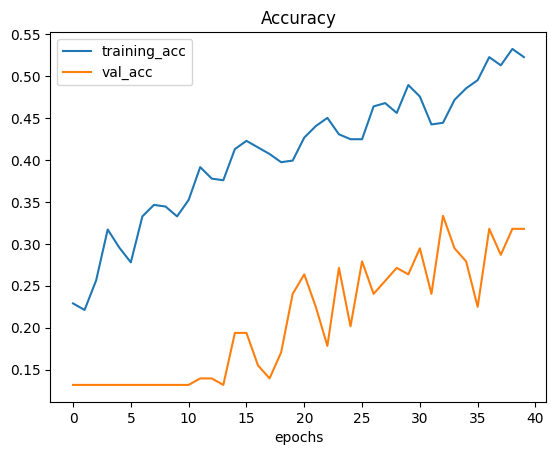

In [91]:
plot_loss_curves(history_2)

In [92]:
import tensorflow as tf
base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=(450,450,3),
                                                           include_top=False,
                                                           weights='imagenet'
                                                          )

<ipython-input-92-f13d09799480>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=(450,450,3),


In [93]:
base_model.trainable = False

In [94]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = Dense(6, activation='softmax')  # Sesuaikan dengan jumlah kelas

inputs = tf.keras.Input(shape=(450, 450, 3))
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs,outputs)

In [95]:
model.compile(loss="categorical_crossentropy",
                optimizer=Adam(),
                metrics=['accuracy'])

history = model.fit(train_data_augmented,
                    epochs=40,
                    validation_data=valid_data)

Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.2499 - loss: 1.8389 - val_accuracy: 0.3798 - val_loss: 1.6879
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 937ms/step - accuracy: 0.4185 - loss: 1.5214 - val_accuracy: 0.4264 - val_loss: 1.4744
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 936ms/step - accuracy: 0.5552 - loss: 1.2476 - val_accuracy: 0.4884 - val_loss: 1.3570
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6054 - loss: 1.1403 - val_accuracy: 0.4651 - val_loss: 1.3798
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 968ms/step - accuracy: 0.5994 - loss: 1.0764 - val_accuracy: 0.4884 - val_loss: 1.3275
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 923ms/step - accuracy: 0.5537 - loss: 1.1647 - val_accuracy: 0.4651 - val_loss: 1.3096
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 920ms/step - accuracy: 0.5792 - loss: 1.0893 - val_accuracy: 0.4574 - val_loss: 1.3415
Epoch 8/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 952ms/step - accuracy: 0.6142 - loss: 0.9706 - val_accuracy: 

In [96]:
# Fine-tuning setelah beberapa epoch
base_model.trainable = True

In [97]:
# Membekukan beberapa lapisan awal agar tidak terlalu overfit
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(1e-5),  # Learning rate yang lebih kecil
              metrics=['accuracy'])

fine_tune_epochs = 40
total_epochs = 40 + fine_tune_epochs

history_fine = model.fit(train_data,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=valid_data)

Epoch 40/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 845ms/step - accuracy: 0.4215 - loss: 1.6741 - val_accuracy: 0.5116 - val_loss: 1.4570
Epoch 41/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.5003 - loss: 1.3526 - val_accuracy: 0.5349 - val_loss: 1.4663
Epoch 42/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.6016 - loss: 1.0041 - val_accuracy: 0.5349 - val_loss: 1.4960
Epoch 43/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.6242 - loss: 0.9622 - val_accuracy: 0.5271 - val_loss: 1.5288
Epoch 44/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.6703 - loss: 0.8974 - val_accuracy: 0.5349 - val_loss: 1.5385
Epoch 45/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - accuracy: 0.7141 - loss: 0.7767 - val_accuracy: 0.5504 - val_loss: 1.5374
Epoch 46/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.7051 - loss: 0.8006 - val_accuracy: 0.5194 - val_loss: 1.5641
Epoch 47/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.7357 - loss: 0.6714 - val_a

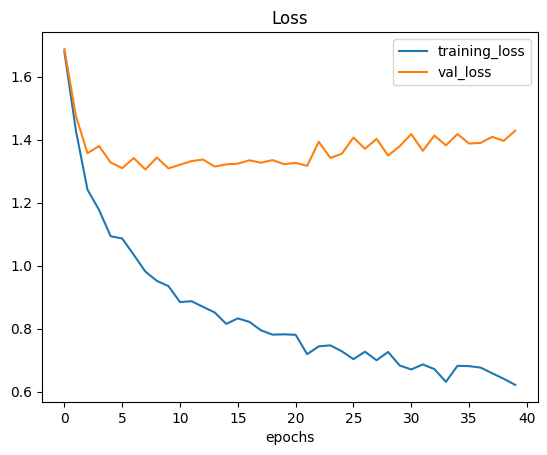

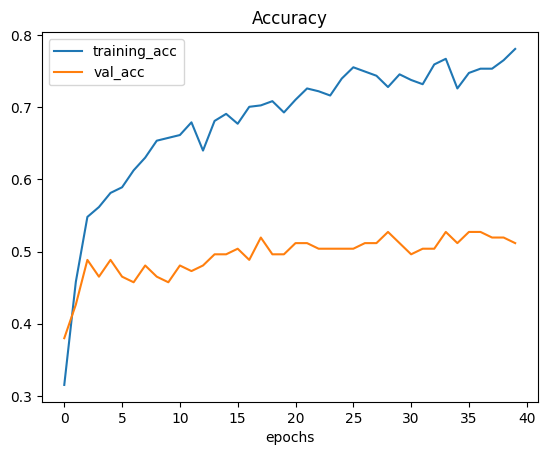

In [98]:
plot_loss_curves(history)